# SpliceAI on ClinVar: splice-effect predictions

Loads the full SpliceAI results (`clinvar_spliceai_scores.tsv`, built by `../12_variant_effect_prediction/splicing/`) -- 4,474,009 variants attempted, 4,137,146 scored (92.5%; the rest came back unscored, likely too close to chromosome ends or in unannotated regions -- a SpliceAI/annotation limitation, not a pipeline problem).

**Data file is not checked into git** -- regenerate via `12_variant_effect_prediction/splicing/merge_spliceai_results.py`, or pull `clinvar_spliceai_scores.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCORE_COLS = ["DS_AG", "DS_AL", "DS_DG", "DS_DL"]
LABELS = ["Acceptor Gain", "Acceptor Loss", "Donor Gain", "Donor Loss"]

## Load data

In [2]:
df = pd.read_csv("clinvar_spliceai_scores.tsv", sep="\t")
print(f"{len(df):,} scored variants")
df.head()

4,137,146 scored variants


,VariationID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,3,0.0,0.00,0.00,0.00,-36,-19,50,47
1,4,0.0,0.00,0.00,0.00,2,-22,1,-22
2,5,0.0,0.03,0.03,0.11,39,-18,-48,39
3,6,0.0,0.02,0.00,0.00,44,25,-5,-26
4,214885,0.0,0.00,0.00,0.00,2,1,27,-31


## Delta score distributions

Each of the four scores ranges 0-1. SpliceAI's own published guidance: >=0.2 suggests a possible splicing effect, >=0.5 is high-confidence. Most variants should score ~0 across all four (no predicted splicing consequence).

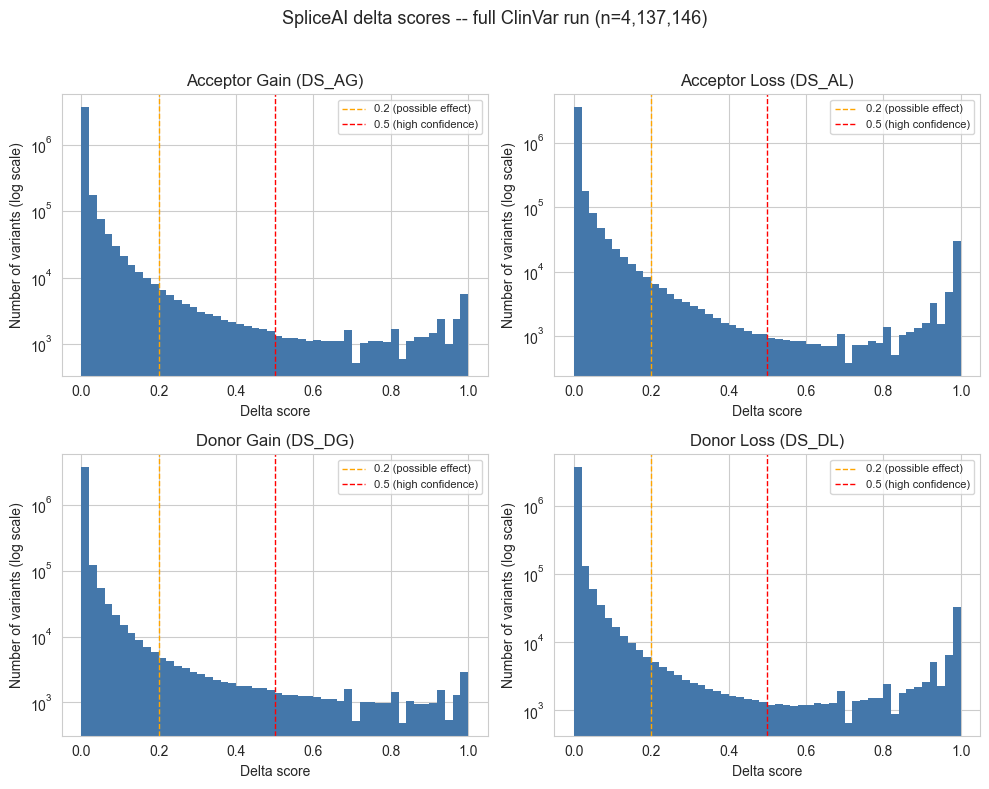

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col, label in zip(axes.flat, SCORE_COLS, LABELS):
    ax.hist(df[col], bins=50, color="#4477AA", edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{label} ({col})")
    ax.set_xlabel("Delta score")
    ax.set_ylabel("Number of variants (log scale)")
    ax.axvline(0.2, color="orange", linestyle="--", linewidth=1, label="0.2 (possible effect)")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 (high confidence)")
    ax.legend(fontsize=8)
fig.suptitle(f"SpliceAI delta scores -- full ClinVar run (n={len(df):,})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary counts

In [4]:
max_score = df[SCORE_COLS].max(axis=1)
print(f"Total scored variants: {len(df):,}")
print(f"Max delta score >= 0.2 (possible splicing effect): {(max_score >= 0.2).sum():,} "
      f"({(max_score >= 0.2).mean()*100:.2f}%)")
print(f"Max delta score >= 0.5 (high-confidence effect): {(max_score >= 0.5).sum():,} "
      f"({(max_score >= 0.5).mean()*100:.2f}%)")

Total scored variants: 4,137,146
Max delta score >= 0.2 (possible splicing effect): 283,525 (6.85%)
Max delta score >= 0.5 (high-confidence effect): 160,205 (3.87%)


## Variants with the strongest predicted splicing effect

In [5]:
top_variants = df.loc[max_score.sort_values(ascending=False).index[:25]]
top_variants[["VariationID"] + SCORE_COLS + ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]].head(25)

,VariationID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
3626478,4331952,0.22,1.00,0.00,0.00,-6,-1,-6,-16
3595614,4295896,1.00,0.29,0.00,0.00,1,6,6,29
3630586,4335108,1.00,0.99,0.00,0.00,-3,-1,-3,29
3727446,4440535,0.00,0.00,0.04,1.00,15,-2,15,-2
3981601,4720016,0.00,0.00,0.53,1.00,8,1,-31,1
3727445,4440534,0.00,0.00,0.03,1.00,16,-1,16,-1
3768126,4477449,0.00,0.00,0.00,1.00,-38,36,-8,2
3230806,3897551,1.00,0.82,0.00,0.00,-1,-7,-7,-14
989601,1304991,0.00,0.00,1.00,0.69,-1,18,-1,18
34762,55879,1.00,0.18,0.00,0.00,-1,21,21,44
